In [1]:
import pandas as pd

# Carrega o dataset bruto - nunca sobrescrevemos este arquivo
df = pd.read_csv("../data/raw/telco_churn.csv")

# 1. Quantas linhas e colunas temos?
print("Shape (linhas, colunas):", df.shape)

# 2. Quais são os tipos de dados de cada coluna?
print("\nTipos de dados:")
print(df.dtypes)

# 3. Existem valores nulos (segundo o pandas)?
print("\nValores nulos por coluna:")
print(df.isnull().sum())

# 4. Distribuição da variável alvo
print("\nDistribuição de Churn:")
print(df['Churn'].value_counts(normalize=True))

df.head()

Shape (linhas, colunas): (7043, 21)

Tipos de dados:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Valores nulos por coluna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingM

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
import pandas as pd

# Tenta converter para número; o que não conseguir vira NaN
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Quantas linhas viraram NaN após a tentativa de conversão?
print("Linhas problemáticas:", total_charges_numeric.isnull().sum())

# Vamos ver quais eram os valores originais dessas linhas problemáticas
print("\nValores originais nessas linhas:")
print(df.loc[total_charges_numeric.isnull(), 'TotalCharges'].unique())

# E qual o tenure (tempo de contrato) dessas linhas? Isso é a hipótese a confirmar
print("\nTenure dessas linhas:")
print(df.loc[total_charges_numeric.isnull(), 'tenure'].unique())

Linhas problemáticas: 11

Valores originais nessas linhas:
<StringArray>
[' ']
Length: 1, dtype: str

Tenure dessas linhas:
[0]


In [4]:
# Converte TotalCharges para número; valores inválidos viram NaN temporariamente
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Preenche os NaN com 0, pois representam clientes novos (tenure = 0) sem cobrança acumulada
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirma que o tipo agora é numérico e não há mais nulos
print("Novo tipo de TotalCharges:", df['TotalCharges'].dtype)
print("Nulos restantes:", df['TotalCharges'].isnull().sum())

df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

Novo tipo de TotalCharges: float64
Nulos restantes: 0


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


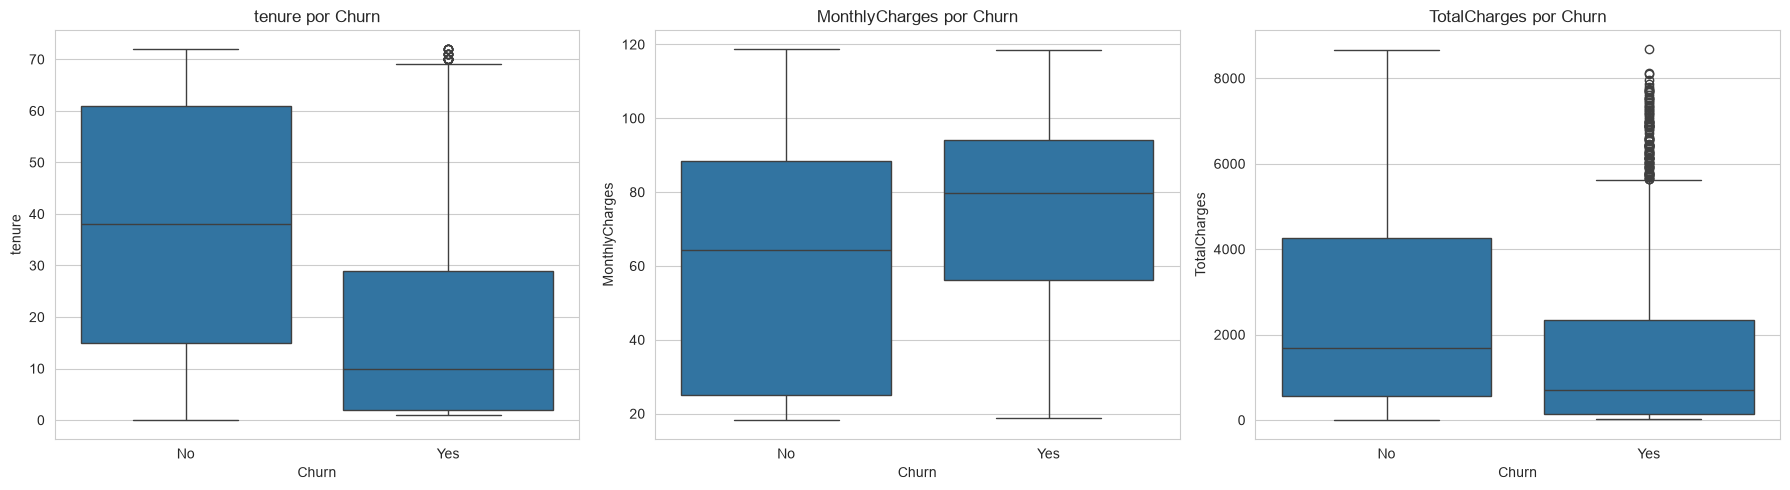

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual básica, para manter consistência nos gráficos
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} por Churn')

plt.tight_layout()
plt.show()

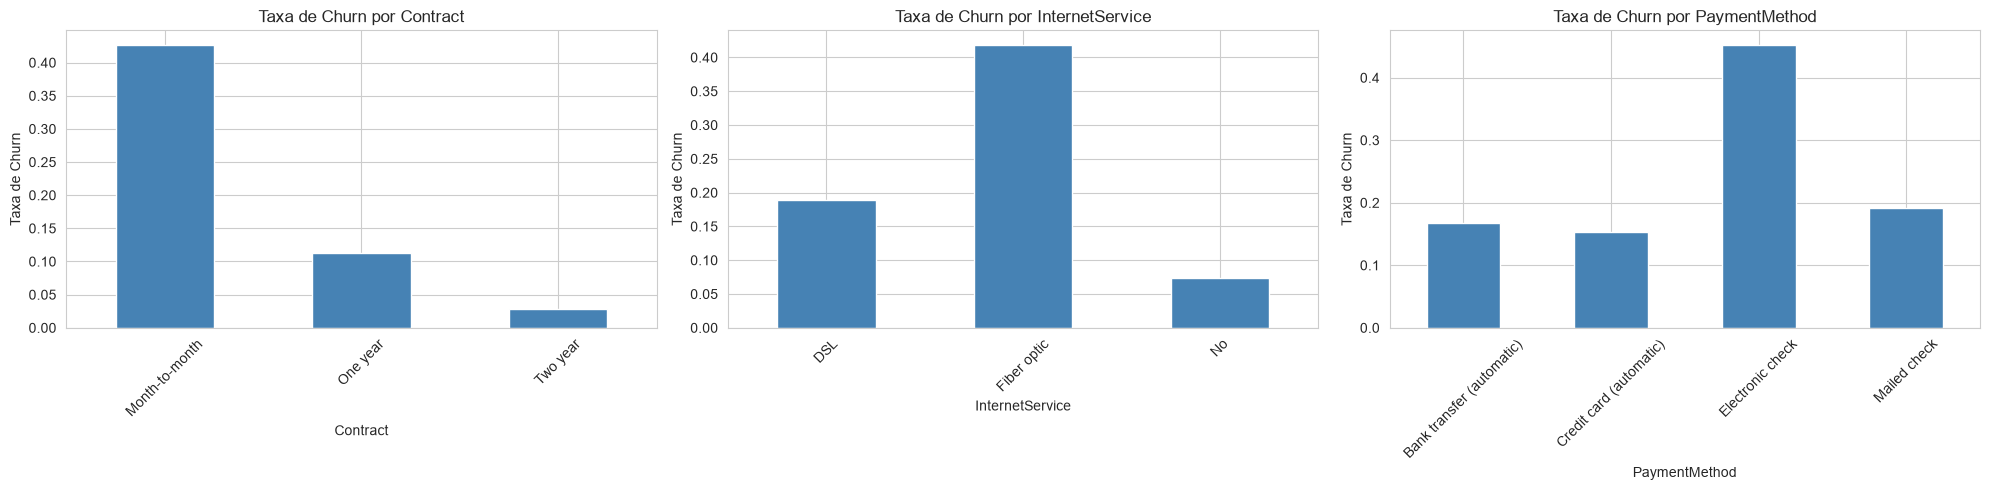

In [6]:
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(categorical_cols):
    # Calcula a proporção de churn (Yes) dentro de cada categoria
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Taxa de Churn por {col}')
    axes[i].set_ylabel('Taxa de Churn')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()